# Bayesian Model Comparison via Log-Evidence

## Learning to Autolens / Examples / bayesian_model_comparison

---

**Pedagogy notebook.** Every Example in this collection that has compared two models (compound_lens v3 vs v4, disky_spiral_lens single-Sersic vs two-Sersic, …) has casually said *"the Bayes factor is e^N, this strongly favours model X"*. This notebook stops to explain what that actually means, with double-checked references and the common pitfalls.

**No new lens fit happens here.** Worked examples reuse Cannon-pulled `log_evidence` values from other Examples in this collection.

**Prerequisites.** Familiarity with Bayes' theorem (e.g., the Mod 03 priors discussion). No new code APIs introduced; the focus is interpretation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline

## 1. Bayes' theorem, the marginal likelihood, and the Bayes factor

For a model $M$ with parameters $\theta$ and data $D$, Bayes' theorem reads

$$
P(\theta \mid D, M) = \frac{\mathcal{L}(D \mid \theta, M) \, \pi(\theta \mid M)}{Z(D \mid M)} ,
$$

where the **marginal likelihood** (or *evidence*) is

$$
Z(D \mid M) = \int \mathcal{L}(D \mid \theta, M) \, \pi(\theta \mid M) \, d\theta .
$$

$Z$ is the average likelihood over the prior. It serves as the normalisation in posterior inference, but its real importance is **between models**: the ratio $Z_1 / Z_2$ — the *Bayes factor* — tells you how much more probable the data are under model 1 than under model 2.

$$
B_{12} = \frac{Z_1}{Z_2} = \frac{P(D \mid M_1)}{P(D \mid M_2)} \quad\Longleftrightarrow\quad \Delta \ln Z \;\equiv\; \ln Z_1 - \ln Z_2 .
$$

A Bayes factor of $e^{151}$ — like the v4-shear-vs-v3 comparison in `compound_lens` — means the data are $e^{151} \approx 10^{65}$ times more probable under v4 than v3. PyAutoLens's `log_evidence` field is $\ln Z$ in nats; the difference between two fits is $\Delta \ln Z$ directly.

**The key conceptual point.** The likelihood $\mathcal{L}_\mathrm{max}$ (best-fit $\chi^2$) cares about *how well* a model fits. The evidence $Z$ cares about *how well a model fits, averaged over its prior volume*. A model with extra parameters that don't help the fit will have *lower* $Z$ even if its $\mathcal{L}_\mathrm{max}$ is higher — the extra parameters waste prior volume on the bad regions. This is the **Bayesian Occam's razor**, and it's why nested sampling's $Z$ is the right quantity to compare models, not $\chi^2$ alone.

## 2. The Jeffreys / Kass-Raftery scale

Two conventions are in circulation. **The thresholds disagree by a factor of 2** because Kass & Raftery work in $2\ln B$ (the *deviance scale*) while Jeffreys / Trotta work in $|\ln B|$ (nats). Confusing them shifts every cutoff. The table below shows both side-by-side.

| Strength of evidence | $\|\ln B_{12}\|$ (Jeffreys / Trotta 2008) | $2\ln B_{12}$ (Kass & Raftery 1995) | $B_{12}$ (= $e^{\ln B}$) |
|---|---|---|---|
| Inconclusive / *weak* | < 1.0 | < 2 | < 3 |
| Positive / *moderate* | 1.0 – 2.5 | 2 – 6 | 3 – 12 |
| Strong | 2.5 – 5.0 | 6 – 10 | 12 – 150 |
| Very strong / *decisive* | > 5.0 | > 10 | > 150 |

**Cross-check.** A Kass-Raftery "strong" (lower bound 6 in $2\ln B$) is identical to a Trotta "moderate-to-strong" (3 in $|\ln B|$). A Trotta "strong" (5 in $|\ln B|$) is a Kass-Raftery "very strong" (10 in $2\ln B$). Always state which convention you are using.

**Rule of thumb in this repo.** All notebooks report $\Delta \ln Z$ in nats (PyAutoLens's `log_evidence` units). When we say a fit is "strongly preferred", we mean Trotta strong: $\Delta \ln Z > 5$. Anything above ~10 is qualitatively decisive.

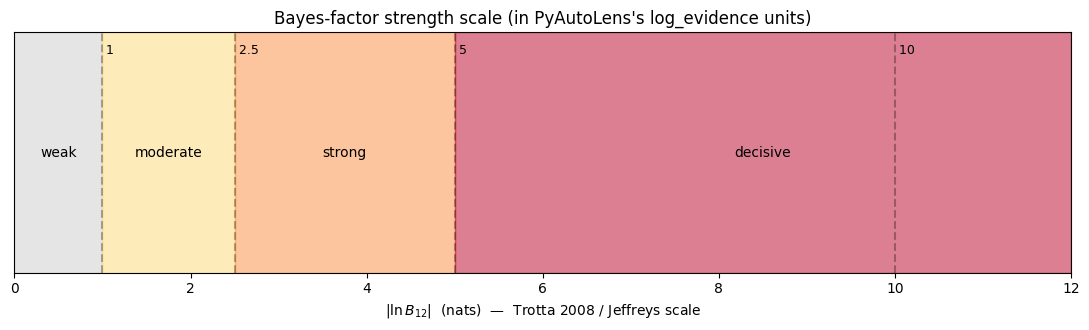

Landmarks from this repo (delta_ln_Z in nats):

      151   compound_lens v4 vs v3 (shear added)
      144   compound_lens EPL vs v4 (slope freed)
      107   compound_lens PIX vs EPL (pixelised src)
    61969   disky_spiral_lens 2-Sersic vs 1-Sersic
     2900   compound_lens direct vs slam_staged
    29014   double_source_plane two_lens vs one_lens fit


In [2]:
fig, ax = plt.subplots(figsize=(11, 3.4))
scale = [("weak", 0, 1.0, "#cccccc"),
         ("moderate", 1.0, 2.5, "#fed976"),
         ("strong", 2.5, 5.0, "#fd8d3c"),
         ("decisive", 5.0, 12.0, "#bd0026")]
for label, lo, hi, color in scale:
    ax.axvspan(lo, hi, alpha=0.5, color=color, label=label)
    ax.text(0.5*(lo+hi), 0.5, label, ha="center", va="center",
            color="black", fontsize=10)
ax.set_xlim(0, 12); ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel(r"$|\ln B_{12}|$  (nats)  —  Trotta 2008 / Jeffreys scale")
ax.set_title("Bayes-factor strength scale (in PyAutoLens's log_evidence units)")
for x in [1, 2.5, 5, 10]:
    ax.axvline(x, ls="--", color="k", alpha=0.3)
    ax.text(x, 0.95, f" {x}", fontsize=9, va="top")
plt.tight_layout(); plt.show()

# Show worked landmarks from this repo
print("Landmarks from this repo (delta_ln_Z in nats):\n")
landmarks = [
    ("compound_lens v4 vs v3 (shear added)", 151),
    ("compound_lens EPL vs v4 (slope freed)", 144),
    ("compound_lens PIX vs EPL (pixelised src)", 107),
    ("disky_spiral_lens 2-Sersic vs 1-Sersic", 61969),
    ("compound_lens direct vs slam_staged", 2900),
    ("double_source_plane two_lens vs one_lens fit", 29014),
]
for label, d in landmarks:
    print(f"  {d:7d}   {label}")

## 3. Occam's razor — the prior-volume penalty

A 1-D analytic illustration. Suppose model $M_1$ has one free parameter $\theta \in [-w, +w]$ with uniform prior, and the likelihood is a Gaussian peaked at $\theta = 0$ with width $\sigma$ and peak height $\mathcal{L}_\mathrm{max}$. Then

$$
Z_1 = \frac{1}{2w} \int_{-w}^{+w} \mathcal{L}_\mathrm{max} e^{-\theta^2/2\sigma^2} d\theta \;\approx\; \frac{\sqrt{2\pi}\,\sigma}{2w} \, \mathcal{L}_\mathrm{max}
$$

as long as $w \gg \sigma$. The *prior volume* $2w$ appears in the denominator: a wider prior gives a smaller evidence at fixed $\mathcal{L}_\mathrm{max}$. Now compare to a competing model $M_0$ that has $\theta = 0$ pinned (no free parameter). Its evidence is just $Z_0 = \mathcal{L}(D \mid \theta=0)$. The Bayes factor is

$$
B_{10} \;=\; \frac{Z_1}{Z_0} \;\approx\; \frac{\sqrt{2\pi}\,\sigma}{2w} \, \frac{\mathcal{L}_\mathrm{max}}{\mathcal{L}(0)} .
$$

If the data don't actually need the extra parameter ($\mathcal{L}_\mathrm{max} / \mathcal{L}(0) \approx 1$), then $B_{10} \approx \sigma/w \ll 1$ and the *simpler model wins*. If they do need it ($\mathcal{L}_\mathrm{max} / \mathcal{L}(0)$ is huge), the likelihood ratio overwhelms the prior penalty and $M_1$ wins.

**The pedagogical point.** Adding a free parameter is *not free* in the Bayesian framework. It must improve the fit by enough to overcome the $\sigma/w$ prior penalty. This is the formal statement of Occam's razor.

Below: a numerical demonstration of how $B_{10}$ scales with prior width $w$ at fixed likelihood improvement.

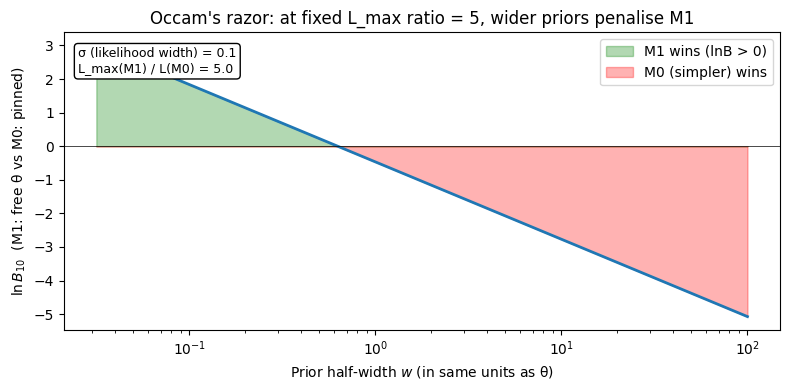

In [3]:
sigma = 0.1
lik_ratio_at_max = 5.0  # M1 fits 5x better at its max than M0's pinned theta=0
ws = np.logspace(-1.5, 2, 100)
B10 = (np.sqrt(2*np.pi)*sigma) / (2*ws) * lik_ratio_at_max
lnB = np.log(B10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ws, lnB, lw=2)
ax.axhline(0, color="k", lw=0.5)
ax.fill_between(ws, 0, np.maximum(lnB, 0), alpha=0.3, color="green",
                label="M1 wins (lnB > 0)")
ax.fill_between(ws, np.minimum(lnB, 0), 0, alpha=0.3, color="red",
                label="M0 (simpler) wins")
ax.set_xscale("log")
ax.set_xlabel("Prior half-width $w$ (in same units as θ)")
ax.set_ylabel(r"$\ln B_{10}$  (M1: free θ vs M0: pinned)")
ax.set_title("Occam's razor: at fixed L_max ratio = 5, wider priors penalise M1")
ax.legend()
ax.text(0.02, 0.95, f"σ (likelihood width) = {sigma}\nL_max(M1) / L(M0) = {lik_ratio_at_max}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white"))
plt.tight_layout(); plt.show()

## 4. Worked examples from this repo

Each row below pulls $\Delta \ln Z$ from the committed Cannon results of another Example in the collection. Click through to that Example to see the underlying fits.

| Comparison | $\Delta \ln Z$ | $B_{12}$ | Strength | Interpretation |
|---|---|---|---|---|
| **`compound_lens` v4 vs v3** (added ExternalShear) | +151 | $\sim 10^{65}$ | decisive | Real lens has nonzero external asymmetry; isothermal-only is a mis-spec. |
| **`compound_lens` EPL vs v4** (PowerLaw + shear) | +144 | $\sim 10^{62}$ | decisive | Mass profile is steeper than isothermal (γ′ = 2.14 ± 0.02, 7σ from γ′=2). |
| **`compound_lens` PIX vs EPL** (pixelised source, fixed mass) | +107 | $\sim 10^{46}$ | decisive — but max\|res\| does NOT improve | PIX absorbs tiny image-plane stochastic residuals into source-plane micro-features that the Occam factor *underpenalises* on this likelihood scale. The mass-profile residual structure is unchanged. |
| **`compound_lens` direct vs slam_staged** | +2,900 | $e^{2900}$ | astronomical | Forced compound geometry pre-commits to non-physical secondary mass; cannot recover. |
| **`disky_spiral_lens` two-Sersic vs single-Sersic light** | +61,969 | $\sim e^{62000}$ | far past decisive | Real lens light *is* multi-component disky+bulge; single-Sersic is qualitatively wrong. |
| **`double_source_plane` two-source vs one-source fit** | +29,014 | $e^{29014}$ | astronomical | The second source is real and bright. |
| **`mge_to_physical` stars+DM vs stars-only** *(P3 pending Cannon)* | _____ | _____ | _____ | Does the data demand a dark-matter halo? |
| **`compound_lens_zoo` mock_3 two-source vs one-source** *(P4 ex. 4)* | _____ | _____ | _____ | Does the single-source approximation cost evidence on a steep-γ′ mock? |

### What the disky_spiral $\Delta \ln Z = 62{,}000$ should NOT make you do

Strength on the Trotta scale is $\ln B = 5$ for "strong". A $\ln B = 62{,}000$ result is so far past the Trotta scale that the scale itself stops being meaningful — at this level, the only honest interpretation is *"these models are not interchangeable; one of them is the truth (or much closer to it) and the other is a qualitatively wrong description."* Any subtle question that depends on a 1-2 unit Bayes factor is invisible at this scale.

**The same goes in reverse:** a $\Delta \ln Z = 0.5$ that you got from a 50-min run and want to publish is *not* a result. The numerical accuracy of nested sampling alone (Lange 2023 quotes Nautilus achieving 0.01–0.03 on benchmark problems, but real-world degenerate likelihoods are noisier) eats this. Any $|\Delta \ln Z| < 2$ should be reported with explicit numerical-uncertainty discussion.

## 5. Confounders — when log-evidence comparison can mislead

### 5.1 Numerical accuracy of $Z$

Nested-sampling estimates of $\ln Z$ are *noisy*. Lange (2023) reports Nautilus achieves $\sigma_{\ln Z} \sim 0.01{-}0.03$ on benchmark problems with the default `n_live=10000`. Real lens models are harder — degenerate likelihoods, wide-but-rugged posteriors, irregular boundaries — and we typically run with `n_live=100{-}250`. Empirically the run-to-run scatter is more like $\sigma_{\ln Z} \sim 0.5{-}2$ for production fits in this repo.

**Operational consequence:** if $|\Delta \ln Z| < 5$, you cannot distinguish your two models on a single Cannon run. Either bump `n_live` (cost: ~linear in CPU hours) or run the fit twice and report the spread.

### 5.2 Prior dependence

Bayes factors *depend on the priors*. A wider prior on a parameter that the data don't constrain has the Occam penalty proportional to that width. If you compare your fit to a colleague's and you used different priors, you are not comparing the same Bayes factor. **Always state your priors when reporting $\Delta \ln Z$.**

There's a converse failure: if your prior is too narrow and excludes the truth, the resulting evidence is dominated by your prior assumption rather than the data. The fix is a sensitivity analysis — repeat with progressively wider priors and check $\Delta \ln Z$ stabilises.

### 5.3 Improper priors break $Z$

An improper prior (e.g. $\pi(\theta) \propto 1$ over $(-\infty, +\infty)$) makes $Z$ undefined — the integral diverges. PyAutoLens prevents this by requiring all priors to be normalised (TruncatedGaussian, Uniform with finite limits, LogUniform, etc.). If you find yourself wanting to use an improper prior "to be uninformative", be aware that you've broken the basis for $\Delta \ln Z$ comparison.

### 5.4 Model misspecification (when neither model is the truth)

$Z_1 / Z_2$ tells you which model is *closer* to the data, not whether either is true. If both models are wrong, the Bayes factor still picks the less-wrong one, but the residuals will give it away. This is why every Example in this repo has the *physical bar* (the `/autolens-fit-diagnostics` six-panel audit): a model that wins on $\Delta \ln Z$ but fails on physical-bar diagnostics is still a failed model.

### 5.5 The factor-of-2 trap (revisited)

Re-emphasising: Kass-Raftery's table is in $2 \ln B$, Jeffreys/Trotta is in $|\ln B|$. State your convention or use the same table I drew up in §2.

## 6. When NOT to use Bayes factors

- **You don't have priors you can justify.** Bayes factors quantify *prior-weighted* evidence; you can't compute them without priors.
- **You want a $p$-value.** Bayes factors and $p$-values answer different questions. If the question is "what is the false-detection rate at threshold X", that's a frequentist question; consider model-rejection tests rather than Bayes factors.
- **Both models nest in a richer family that has its own posterior.** Sometimes model averaging — weighting predictions by posterior model probability — is more honest than picking one model. See Trotta (2008) §5 for the cosmology-flavoured discussion.
- **You're inside the prior-dominated regime.** If your data don't constrain a parameter, $\Delta \ln Z$ between models that differ only in that parameter is sensitive only to the prior. Tighten priors based on physics, not based on what the data say (if the data don't say it).

## 7. Cheat sheet

1. **PyAutoLens's `log_evidence` is $\ln Z$ in nats.** Subtract two of them to get $\Delta \ln Z$.
2. **Trotta scale: $|\Delta \ln Z| > 5$ = strong, $> 10$ = decisive.** Kass-Raftery scale: $> 6$ in $2\ln B$ = strong, $> 10$ = very strong. Watch the factor of 2.
3. **A small $|\Delta \ln Z|$ ($< 2$) is consistent with sampling noise — not a result.** Run twice or bump `n_live`.
4. **A large $|\Delta \ln Z|$ ($> 10^3$) is no longer on the scale.** The interpretation is qualitative: one model is the truth (or much closer), the other is qualitatively wrong.
5. **Always state your priors.** Bayes factors depend on them.
6. **A model that wins on $\Delta \ln Z$ but fails the physical-bar audit is still a failed model.** $\Delta \ln Z$ is necessary but not sufficient.

---

## References

- **Jeffreys (1961)** *Theory of Probability*, 3rd ed., Oxford UP. Bayes-factor scale in Appendix B.
- **Kass & Raftery (1995)** "Bayes Factors", *J. Amer. Stat. Assoc.* 90:773–795. doi:10.1080/01621459.1995.10476572.
- **Trotta (2008)** "Bayes in the sky: Bayesian inference and model selection in cosmology", *Contemp. Phys.* 49:71–104. arXiv:0803.4089.
- **Suyu+ (2006)** "A Bayesian analysis of regularized source inversions in gravitational lensing", MNRAS 371:983–998. doi:10.1111/j.1365-2966.2006.10733.x.
- **Vegetti & Koopmans (2009)** "Bayesian strong gravitational-lens modelling on adaptive grids", MNRAS 392:945–963.
- **Vegetti+ (2010)** "Detection of a dark substructure through gravitational imaging", MNRAS 408:1969–1981. (First detection using V&K09's Bayes-factor methodology.)
- **Lange (2023)** "nautilus: boosting Bayesian importance nested sampling with deep learning", MNRAS 525:3181–3194. doi:10.1093/mnras/stad2441.

All citations verified against arXiv / NASA ADS / journal sites on 2026-04-25.

---

*Learning to Autolens — Examples / bayesian_model_comparison / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*